# Predicting MPG from Horsepower — Linear Regression from Scratch

Gradient descent linear regression implemented without scikit-learn, using the [Auto MPG dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg) (UCI).

Two features are used — `horsepower` and `horsepower²` — so the fit is actually a quadratic curve, built with the same linear-regression math (the model is linear in its parameters `w1, w2, b`, even though it's quadratic in horsepower).

**Model:** $f(x_1,x_2) = w_1x_1 + w_2x_2 + b$
**Cost:** $J = \frac{1}{2m}\sum (f(x)-y)^2$
**Gradients:** $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum(f(x)-y)x_j$, $\frac{\partial J}{\partial b} = \frac{1}{m}\sum(f(x)-y)$
**Update:** $w \mathrel{-}= \alpha\frac{\partial J}{\partial w}$, $b \mathrel{-}= \alpha\frac{\partial J}{\partial b}$

In [226]:
pip install ucimlrepo

Installs `ucimlrepo` to fetch the dataset directly from the UCI repository.

In [227]:
from ucimlrepo import fetch_ucirepo 

  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# metadata 
print(auto_mpg.metadata) 
  
# variable information 
print(auto_mpg.variables) 

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Loads the Auto MPG dataset (id=9) into `X` (features) and `y` (target = `mpg`).

In [228]:
import numpy as np
import pandas as pd
import seaborn as sns

Standard imports: `numpy` for the math, `pandas` for the DataFrame, `seaborn` for the final plot.

In [229]:
df = pd.concat([X, y], axis=1)

Combines features and target into a single DataFrame.

In [230]:
df = df.dropna()
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0


Drops rows with missing `horsepower` (398 → 392 rows).

In [231]:
df['hpsq'] = df['horsepower'] ** 2
df['hpsq'] = df['hpsq'] / df['hpsq'].mean()

Adds `horsepower²` as a second feature (`hpsq`, scaled by its own mean) — this is what makes the fit a curve instead of a straight line.

In [232]:
df['horsepower'] = df['horsepower'] / df['horsepower'].mean()
df['mpg'] = df['mpg'] / df['mpg'].mean()

Scales `horsepower` and `mpg` by their means too, so all inputs are on a similar scale — this helps gradient descent converge evenly across both weights.

In [233]:
horsepower = df['horsepower'].to_numpy()
hpsq = df['hpsq'].to_numpy()
mpg = df['mpg'].to_numpy()

Converts the normalized columns to numpy arrays for the vectorized math below.

In [234]:
def FWB(w1, w2, b, feature1, feature2):
    return w1*(feature1) + w2*(feature2) + b

**Model function `FWB`:** $f(x_1,x_2) = w_1x_1 + w_2x_2 + b$.

In [235]:
def calc_error(w1, w2, b, feature1, feature2, target):
    prediction = FWB(w1, w2, b, feature1, feature2)
    error = prediction - target
    return error

**`calc_error`:** residual (prediction − target), reused by the cost and gradient functions.

In [236]:
def JWB(target, feature1, feature2, w1, w2, b):
    error = calc_error(w1, w2, b, feature1, feature2, target)
    sq_error = error**2
    size = len(sq_error)
    total = np.sum(sq_error) / (size * 2)
    return total

**Cost function `JWB`:** mean squared error, halved — the quantity gradient descent minimizes.

In [237]:
JWB(mpg, horsepower, hpsq, 0, 0, 0)

np.float64(0.5552678850390551)

Cost at `w1=w2=b=0`, as a baseline before training (~0.555).

In [238]:
def DW_JWB(target, feature1, feature2, w1, w2, b, Xfeature):
    error = calc_error(w1, w2, b, feature1, feature2, target)
    algo = error * Xfeature
    size = len(algo)
    total = np.sum(algo) / (size)
    return total

**`DW_JWB`:** gradient of the cost w.r.t. a weight — average of residual × feature, i.e. $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum(f(x)-y)x_j$.

In [239]:
def DB_JWB(target, feature1, feature2, w1, w2, b):
    error = calc_error(w1, w2, b, feature1, feature2, target)
    size = len(error)
    total = np.sum(error) / (size)
    return total

**`DB_JWB`:** gradient of the cost w.r.t. the bias — average residual.

In [240]:
def GDB(target, feature1, feature2, alpha, num_iters):
    w1 = 0
    w2 = 0
    b = 0
    cost_history = []
    
    for i in range(num_iters):
        temp_w1 = alpha*(DW_JWB(target, feature1, feature2, w1, w2, b, feature1))
        temp_w2 = alpha*(DW_JWB(target, feature1, feature2, w1, w2, b, feature2))
        temp_b = alpha*(DB_JWB(target, feature1, feature2, w1, w2, b))

        w1 -= temp_w1
        w2 -= temp_w2
        b -= temp_b

        cost_history.append(JWB(target, feature1, feature2, w1, w2, b))

    print(w1, w2, b)
    return cost_history

**`GDB`:** the training loop. Each iteration computes all three gradients from the current `w1, w2, b`, then updates them simultaneously, and logs the cost to `cost_history`.

In [241]:
cost_history = GDB(mpg, hpsq, horsepower, 0.2, 10000)

0.6479409229010733 -2.071926284729682 2.4239764973083484


Trains for 10,000 iterations at `alpha=0.2` → `w1 ≈ 0.648` (hpsq), `w2 ≈ -2.072` (horsepower), `b ≈ 2.424`. The negative horsepower weight paired with a positive hpsq weight gives the expected shape: mpg drops fast at low horsepower, then the drop flattens/curves.

<Axes: >

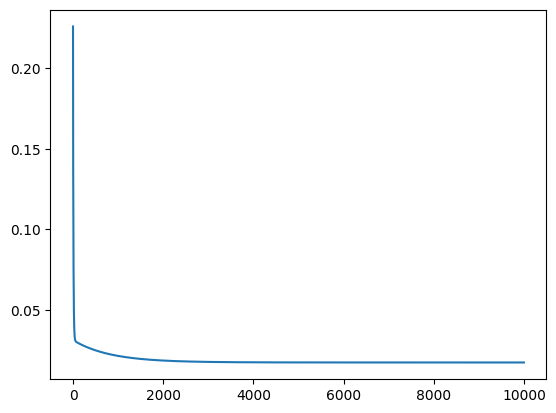

In [242]:
sns.lineplot(x=np.arange(10000), y=cost_history)

Plots `cost_history` over the 10,000 iterations — the learning curve. It should drop steeply at first and flatten out as gradient descent converges toward the minimum.

<Axes: >

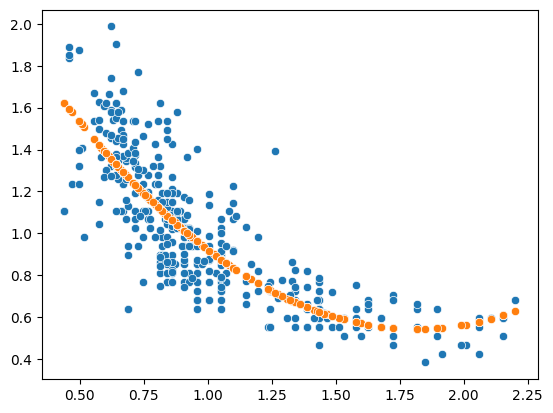

In [243]:
f = hpsq * 0.6479409229010733   + horsepower * -2.071926284729682  + 2.4239764973083484
sns.scatterplot(x=horsepower, y=mpg)
sns.scatterplot(x=horsepower, y=f)

Plots the actual normalized `mpg` against `horsepower`, overlaid with the model's predictions `f` — a visual check of how well the fitted curve matches the data.

---
*This documentation was written with Claude's help; all the modeling code above is my own.*